In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('bmw_global_sales_dataset.csv')
df.head()

,year,month,country,model,segment,engine_type,price_usd,units_sold
0,2015,1,France,3 Series,SUV,Hybrid,"$55,827",706
1,2015,1,USA,7 Series,Electric,Hybrid,"$60,186",922
2,2015,1,China,i4,SUV,Hybrid,"$1,18,384",368
3,2015,1,Germany,i7,SUV,Diesel,"$44,943",647
4,2015,1,China,iX,Sedan,Petrol,"$63,633",941


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         1000 non-null   int64 
 1   month        1000 non-null   int64 
 2   country      1000 non-null   object
 3   model        1000 non-null   object
 4   segment      1000 non-null   object
 5   engine_type  1000 non-null   object
 6    price_usd   1000 non-null   object
 7   units_sold   1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [21]:
df.columns = df.columns.str.strip()

df['price_usd'] = df['price_usd'].replace('[$,]', '', regex=True)
df['price_usd'] = df['price_usd'].astype(float)

df.isnull().sum()

year           0
month          0
country        0
model          0
segment        0
engine_type    0
price_usd      0
units_sold     0
dtype: int64

In [22]:
total_sales = df['units_sold'].sum()
print('Total Units Sold:', total_sales)

Total Units Sold: 633192


In [23]:
country_sales = df.groupby('country')['units_sold'].sum().sort_values(ascending=False)
country_sales

country
China        77488
UK           70639
France       67173
India        65898
Brazil       64331
Australia    61987
Germany      59006
Japan        58076
Canada       55947
USA          52647
Name: units_sold, dtype: int64

In [24]:
model_sales = df.groupby('model')['units_sold'].sum().sort_values(ascending=False)
model_sales

model
X3          73358
3 Series    70886
i4          69528
X5          65505
7 Series    65071
i7          63974
X1          61341
5 Series    59144
X7          53318
iX          51067
Name: units_sold, dtype: int64

In [25]:
engine_sales = df.groupby('engine_type')['units_sold'].sum()
engine_sales

engine_type
Diesel      157598
Electric    170694
Hybrid      159624
Petrol      145276
Name: units_sold, dtype: int64

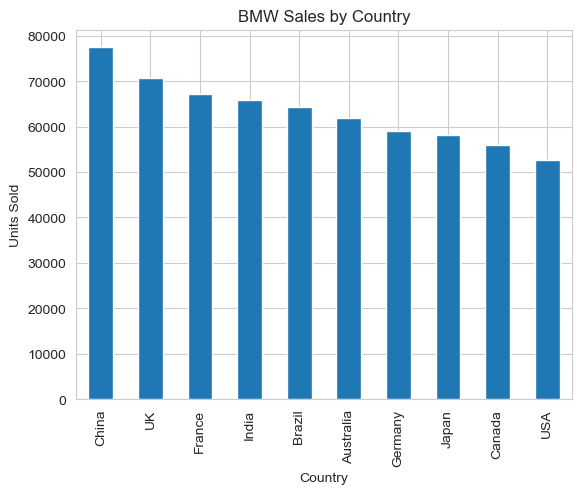

In [26]:
country_sales.plot(kind='bar')
plt.title('BMW Sales by Country')
plt.ylabel('Units Sold')
plt.xlabel('Country')
plt.show()

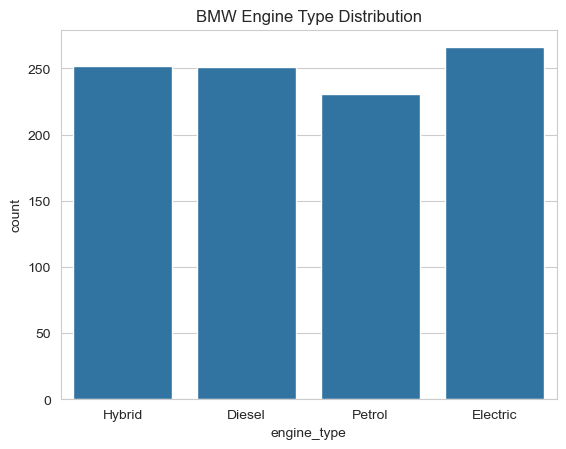

In [27]:
sns.countplot(x='engine_type', data=df)
plt.title('BMW Engine Type Distribution')
plt.show()

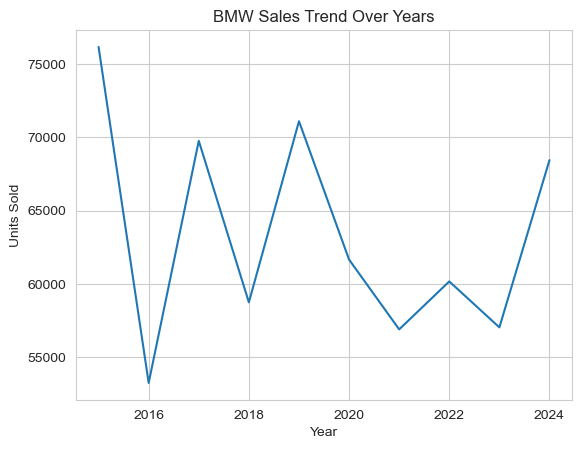

In [28]:
year_sales = df.groupby('year')['units_sold'].sum()

plt.plot(year_sales)
plt.title('BMW Sales Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.show()